In [4]:
from asmcmc.initialize import RandomLatticeInitializer, ColumnarLatticeInitializer, FrameInitializer
from asmcmc.metropolis import MetropolisCalculator
from asmcmc.potentials import GBQPotential, CACELLI_POTENTIAL
from asmcmc.measurements import (
    TrajectoryAnalyzer, 
    RadialDistributionFunction, 
    OrientationalCorrelationFunction, 
    HeatCapacity, 
    NematicOrderParameter, 
    AverageEnthalpy
)

import pickle
import os

import matplotlib.pyplot as plt
import numpy as np

from ase.db import connect
import ase.db
import ase.io

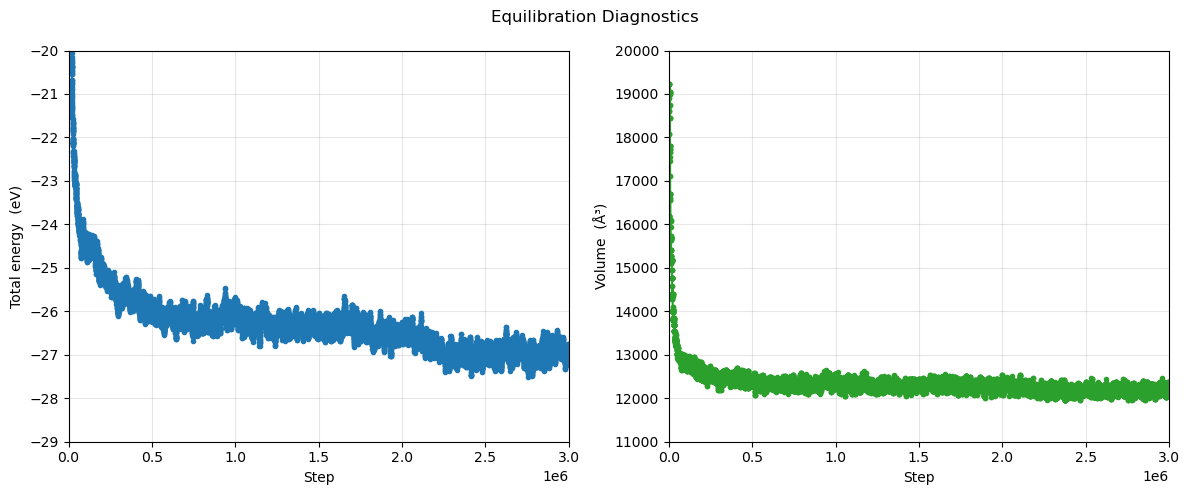

In [12]:
steps, energy, vol = [], [], []
with connect("../results/validation/100.0_6.324209e-06/dense/equilibration.db") as db:
    for row in db.select():
        steps.append(row.step)
        energy.append(row.total_energy)
        vol.append(row.vol)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

MIN_STEP = 0
MAX_STEP = max(steps)

MIN_ENERGY = -29
MAX_ENERGY = -20

MIN_VOL = 11_000
MAX_VOL = 20_000


def fit_line(ax, x, y, xlim, ylim):
    """Fit a line to the points inside the (xlim, ylim) window and draw it.

    Masking against the same bounds used for the axes means the fit
    follows the plot window: change MIN_*/MAX_* and the line updates.
    """
    x, y = np.asarray(x), np.asarray(y)
    (xlo, xhi), (ylo, yhi) = xlim, ylim
    mask = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    xs = np.array([xlo, xhi])
    ax.plot(xs, slope * xs + intercept, color="black", ls="--",
            label=f"fit: {slope:.3g}·step + {intercept:.3g}")
    ax.legend()


axs[0].plot(steps, energy, marker=".")
axs[0].set_ylabel("Total energy  (eV)")
# fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

axs[1].plot(steps, vol, marker=".", color="tab:green")
axs[1].set_ylabel("Volume  (Å³)")
# fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

for ax in axs:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

axs[0].set_xbound(MIN_STEP, max(steps))
axs[1].set_xbound(MIN_STEP, max(steps))

axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Equilibration Diagnostics")
fig.tight_layout()

# fig.savefig("../results/validation/100.0_6.324209e-06/dense/equilibration_diagnostics.png", dpi=150)

plt.show()

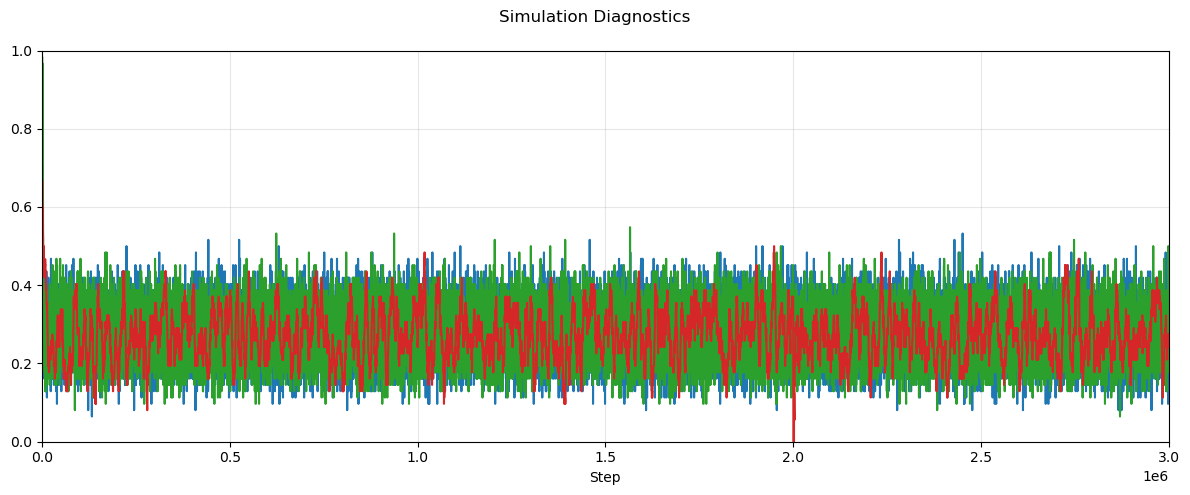

In [13]:
steps, pos_acc, or_acc, vol_acc = [], [], [], []
with connect("../results/validation/100.0_6.324209e-06/dense/equilibration.db") as db:
    for row in db.select():
        steps.append(row.step)
        pos_acc.append(row.pos_acc_rate)
        or_acc.append(row.or_acc_rate)
        vol_acc.append(row.vol_acc_rate)


fig, ax = plt.subplots(figsize=(12, 5))

MIN_STEP = 0
MAX_STEP = max(steps)

ax.plot(steps, pos_acc, label="Position Move Acceptance")
# fit_line(axs[0], steps, energy, (MIN_STEP, MAX_STEP), (MIN_ENERGY, MAX_ENERGY))

ax.plot(steps, or_acc, color="tab:green", label="Orientation Move Acceptance")
# fit_line(axs[1], steps, vol, (MIN_STEP, MAX_STEP), (MIN_VOL, MAX_VOL))

ax.plot(steps, vol_acc, color="tab:red", label="Volume Move Acceptance")

ax.set_xlabel("Step")
ax.grid(True, alpha=0.3)

ax.set_xbound(MIN_STEP, max(steps))
ax.set_ybound(0, 1)

# axs[0].set_ybound(MIN_ENERGY, MAX_ENERGY)
# axs[1].set_ybound(MIN_VOL, MAX_VOL)


fig.suptitle("Simulation Diagnostics")
fig.tight_layout()

# fig.savefig("../results/validation/100.0_6.324209e-06/simulation_diagnostics.png", dpi=150)

plt.show()

In [ ]:
WRITE_XYZ = True
if WRITE_XYZ:
    eq_traj = []
    with ase.db.connect("../results/validation/100.0_6.324209e-06/dilute/stage05_P6.32421e-06/equilibration.db") as db:
        for row in db.select():
            atoms = row.toatoms()
            atoms.new_array("c_q", np.asarray(row.data["c_q"]))
            atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
            atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for a in atoms]))
            eq_traj.append(atoms)
        


FileNotFoundError: [Errno 2] No such file or directory: '../results/validation/100.0_6.324209e-06/dense/stage05_P6.32421e-06/equilibration.xyz'

In [7]:
if WRITE_XYZ:
    ase.io.write(
        "../results/validation/100.0_6.324209e-06/dilute/stage05_P6.32421e-06/equilibration.xyz", 
        eq_traj, 
        format="extxyz"
    )


In [14]:
# sim_traj = []

# with connect("../results/validation/100.0_6.324209e-06/dense/simulation.db") as db:
#     for row in db.select():
#         atoms = row.toatoms()
#         atoms.new_array("c_q", np.asarray(row.data["c_q"]))
#         atoms.new_array("or_vec", np.asarray(row.data["or_vec"]))
#         atoms.new_array("shape", np.asarray([[2.5, 2.5, 1.0] for a in atoms]))
#         sim_traj.append(atoms)

# ase.io.write("../results/validation/100.0_6.324209e-06/dense/simulation.xyz", sim_traj, format="extxyz")

In [ ]:
import json

RUN_DIR = "../results/validation/100.0_6.324209e-06/dense"

# Pull the state point straight from the run's write-once config so the
# measurements stay consistent with how the trajectory was generated.
with open(f"{RUN_DIR}/run_config.json") as f:
    config = json.load(f)

temp = config["temp"]
pressure = config["pressure"]
n_particles = config["init"]["init_n_particles"]

# r_max stays below half the (NPT-fluctuating) box: the RDF/OCF only fill bins
# inside each frame's L/2, and the smallest L/2 over this run is ~11.0 A.
R_MAX = 9.0
NUM_BINS = 90

In [16]:
# Run every measurement over the trajectory and cache the results to a pickle.
# Re-running this cell loads the cached results instead of re-scanning the
# 12k-frame db; delete the pickle to force a recompute.
results_path = f"{RUN_DIR}/analysis_results.pkl"

if os.path.exists(results_path):
    with open(results_path, "rb") as f:
        results = pickle.load(f)
    print(f"Loaded cached results from {results_path}")
else:
    analyzer = TrajectoryAnalyzer(f"{RUN_DIR}/simulation.db")
    analyzer.add_measurement("rdf", RadialDistributionFunction(R_MAX, NUM_BINS))
    analyzer.add_measurement("ocf", OrientationalCorrelationFunction(R_MAX, NUM_BINS))
    analyzer.add_measurement("nematic", NematicOrderParameter())
    analyzer.add_measurement("enthalpy", AverageEnthalpy(pressure))
    analyzer.add_measurement("heat_capacity", HeatCapacity(temp, n_particles, pressure=pressure))
    results = analyzer.run_analysis()
    with open(results_path, "wb") as f:
        pickle.dump(results, f)
    print(f"Saved results to {results_path}")

results

Analyzing Trajectory:   0%|          | 0/16000 [00:00<?, ?it/s]

Saved results to ../results/validation/100.0_6.324209e-06/dense/analysis_results.pkl


{'rdf': {'r': array([ 0.05,  0.15,  0.25,  0.35,  0.45,  0.55,  0.65,  0.75,  0.85,
          0.95,  1.05,  1.15,  1.25,  1.35,  1.45,  1.55,  1.65,  1.75,
          1.85,  1.95,  2.05,  2.15,  2.25,  2.35,  2.45,  2.55,  2.65,
          2.75,  2.85,  2.95,  3.05,  3.15,  3.25,  3.35,  3.45,  3.55,
          3.65,  3.75,  3.85,  3.95,  4.05,  4.15,  4.25,  4.35,  4.45,
          4.55,  4.65,  4.75,  4.85,  4.95,  5.05,  5.15,  5.25,  5.35,
          5.45,  5.55,  5.65,  5.75,  5.85,  5.95,  6.05,  6.15,  6.25,
          6.35,  6.45,  6.55,  6.65,  6.75,  6.85,  6.95,  7.05,  7.15,
          7.25,  7.35,  7.45,  7.55,  7.65,  7.75,  7.85,  7.95,  8.05,
          8.15,  8.25,  8.35,  8.45,  8.55,  8.65,  8.75,  8.85,  8.95,
          9.05,  9.15,  9.25,  9.35,  9.45,  9.55,  9.65,  9.75,  9.85,
          9.95, 10.05, 10.15, 10.25, 10.35, 10.45, 10.55, 10.65, 10.75,
         10.85, 10.95]),
  'g_r': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000

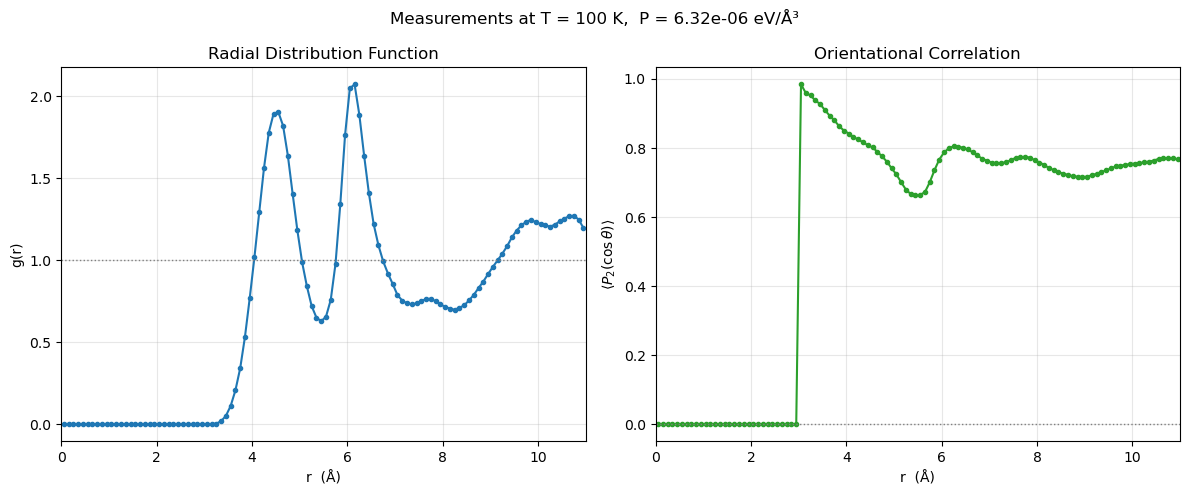

Nematic order:  S = 0.864 ± 0.009  (S_lab = 0.864)
Director:       [-0.068 -0.049 -0.997]
Enthalpy:       H = -27.114 ± 0.219 eV   (H/N = -0.2169 eV)
Heat capacity:  C_p = 7.031e-04 eV/K/particle  (8.16 k_B/particle)


In [17]:
from asmcmc.measurements import BOLTZCONST

rdf = results["rdf"]
ocf = results["ocf"]
nematic = results["nematic"]
H_mean, H_std = results["enthalpy"]
cp = results["heat_capacity"]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Radial distribution function g(r): positional order
axs[0].plot(rdf["r"], rdf["g_r"], marker=".")
axs[0].axhline(1.0, color="gray", ls=":", lw=1)
axs[0].set_xlabel("r  (Å)")
axs[0].set_ylabel("g(r)")
axs[0].set_title("Radial Distribution Function")

# Orientational correlation <P2(cos θ)>(r): neighbour alignment vs separation
axs[1].plot(ocf["r"], ocf["s2_r"], marker=".", color="tab:green")
axs[1].axhline(0.0, color="gray", ls=":", lw=1)
axs[1].set_xlabel("r  (Å)")
axs[1].set_ylabel(r"$\langle P_2(\cos\theta)\rangle$")
axs[1].set_title("Orientational Correlation")

for ax in axs:
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, R_MAX)

fig.suptitle(f"Measurements at T = {temp:g} K,  P = {pressure:.3g} eV/Å³")
fig.tight_layout()

# fig.savefig(f"{RUN_DIR}/measurements.png", dpi=150)

plt.show()

# Scalar observables
print(f"Nematic order:  S = {nematic['S']:.3f} ± {nematic['S_std']:.3f}  (S_lab = {nematic['S_lab']:.3f})")
print(f"Director:       {np.array2string(nematic['director'], precision=3)}")
print(f"Enthalpy:       H = {H_mean:.3f} ± {H_std:.3f} eV   (H/N = {H_mean / n_particles:.4f} eV)")
print(f"Heat capacity:  C_p = {cp:.3e} eV/K/particle  ({cp / BOLTZCONST:.2f} k_B/particle)")